### 소희 -상품분석서비스(점포_상권)

In [2]:
from pathlib import Path
import pandas as pd
import zipfile
import shutil

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent
target_dir = project_root / 'data' / '01_영역'

# 연도별 파일명 (2024만 다름)
csv_names = {
    2019: '서울시_상권분석서비스(점포-상권)_2019년.csv',
    2020: '서울시_상권분석서비스(점포-상권)_2020년.csv',
    2021: '서울시_상권분석서비스(점포-상권)_2021년.csv',
    2022: '서울시_상권분석서비스(점포-상권)_2022년.csv',
    2023: '서울시_상권분석서비스(점포-상권)_2023년.csv',
    2024: '서울시 상권분석서비스(점포-상권)_2024년.csv',  # 공백!
}

dfs = {}

for year, csv_name in csv_names.items():
    csv_path = target_dir / csv_name
    
    if not csv_path.exists():
        print(f'📦 {year} CSV 없음, zip 찾는 중...')
        raw_dir = project_root / 'data' / 'raw'
        zip_files = list(raw_dir.glob(f'*점포*{year}*.zip'))
        
        if not zip_files:
            print(f'  ⚠️ {year} zip 없음, 건너뜀')
            continue
        
        zip_path = zip_files[0]
        target_dir.mkdir(parents=True, exist_ok=True)
        
        with zipfile.ZipFile(zip_path, 'r') as z:
            for info in z.infolist():
                if info.filename.startswith('__MACOSX'):
                    continue
                try:
                    filename = info.filename.encode('cp437').decode('utf-8')
                except:
                    filename = info.filename
                if info.is_dir():
                    continue
                out_path = target_dir / filename
                out_path.parent.mkdir(parents=True, exist_ok=True)
                with z.open(info) as src, open(out_path, 'wb') as dst:
                    shutil.copyfileobj(src, dst)
    
    df = pd.read_csv(csv_path, encoding='cp949')
    dfs[year] = df
    print(f'✅ {year} 로드 완료: {df.shape}')

df_전체 = pd.concat(dfs.values(), ignore_index=True)
print(f'\n📊 전체 데이터: {df_전체.shape}')

✅ 2019 로드 완료: (297369, 14)
✅ 2020 로드 완료: (310459, 14)
✅ 2021 로드 완료: (303880, 14)
✅ 2022 로드 완료: (305587, 14)
✅ 2023 로드 완료: (307741, 14)
✅ 2024 로드 완료: (306889, 14)

📊 전체 데이터: (1831925, 14)


In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'AppleGothic'  # Mac 한글 폰트
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 기호 깨짐 방지

* 전년도 불러오기 = df_전체
* 연도별 불러오기 = dfs[2019]

In [4]:
# 연도/분기 기준으로 잘 집계되어있는지 확인.
display(dfs[2019]['기준_년분기_코드'].unique())
display(dfs[2020]['기준_년분기_코드'].unique())
display(dfs[2021]['기준_년분기_코드'].unique())
display(dfs[2022]['기준_년분기_코드'].unique())
display(dfs[2024]['기준_년분기_코드'].unique())

array([20191, 20192, 20193, 20194])

array([20201, 20202, 20203, 20204])

array([20211, 20212, 20213, 20214])

array([20221, 20222, 20223, 20224])

array([20241, 20242, 20243, 20244])

In [5]:
# 점포수 null 값 확인
df_전체[['점포_수','유사_업종_점포_수','개업_율','폐업_률','폐업_점포_수','프랜차이즈_점포_수']].isnull().sum()

점포_수          0
유사_업종_점포_수    0
개업_율          0
폐업_률          0
폐업_점포_수       0
프랜차이즈_점포_수    0
dtype: int64

In [6]:
#음수값 있는지 확인
(df_전체[['점포_수','유사_업종_점포_수','개업_율','폐업_률','폐업_점포_수','프랜차이즈_점포_수']]<0).sum()

점포_수          0
유사_업종_점포_수    0
개업_율          0
폐업_률          0
폐업_점포_수       0
프랜차이즈_점포_수    0
dtype: int64

In [7]:
# 상품 구분코드가 어떤 명인지 확인.
display(dfs[2019][dfs[2019]['상권_구분_코드']=='A'][[ '상권_구분_코드', '상권_구분_코드_명']])
display(dfs[2019][dfs[2019]['상권_구분_코드']=='D'][[ '상권_구분_코드', '상권_구분_코드_명']])
display(dfs[2019][dfs[2019]['상권_구분_코드']=='R'][[ '상권_구분_코드', '상권_구분_코드_명']])
display(dfs[2019][dfs[2019]['상권_구분_코드']=='U'][[ '상권_구분_코드', '상권_구분_코드_명']])

,상권_구분_코드,상권_구분_코드_명
0,A,골목상권
1,A,골목상권
2,A,골목상권
3,A,골목상권
4,A,골목상권
...,...,...
268591,A,골목상권
268592,A,골목상권
268593,A,골목상권
268594,A,골목상권


,상권_구분_코드,상권_구분_코드_명
45369,D,발달상권
45370,D,발달상권
45371,D,발달상권
45372,D,발달상권
45373,D,발달상권
...,...,...
286282,D,발달상권
286283,D,발달상권
286284,D,발달상권
286285,D,발달상권


,상권_구분_코드,상권_구분_코드_명
62913,R,전통시장
62914,R,전통시장
62915,R,전통시장
62916,R,전통시장
62917,R,전통시장
...,...,...
296855,R,전통시장
296856,R,전통시장
296857,R,전통시장
296858,R,전통시장


,상권_구분_코드,상권_구분_코드_명
73358,U,관광특구
73359,U,관광특구
73360,U,관광특구
73361,U,관광특구
73362,U,관광특구
...,...,...
297364,U,관광특구
297365,U,관광특구
297366,U,관광특구
297367,U,관광특구


In [8]:
#2019~2024 null 값 없음.
df_전체.info()

<class 'pandas.DataFrame'>
RangeIndex: 1831925 entries, 0 to 1831924
Data columns (total 14 columns):
 #   Column       Dtype
---  ------       -----
 0   기준_년분기_코드    int64
 1   상권_구분_코드     str  
 2   상권_구분_코드_명   str  
 3   상권_코드        int64
 4   상권_코드_명      str  
 5   서비스_업종_코드    str  
 6   서비스_업종_코드_명  str  
 7   점포_수         int64
 8   유사_업종_점포_수   int64
 9   개업_율         int64
 10  개업_점포_수      int64
 11  폐업_률         int64
 12  폐업_점포_수      int64
 13  프랜차이즈_점포_수   int64
dtypes: int64(9), str(5)
memory usage: 195.7 MB


# 상권 규모 분석

* 연도별 상권별 점포수 (트렌드)

In [9]:

# 연도 컬럼 추가 (앞 4자리만 추출)
df_전체['연도'] = df_전체['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 연도 + 상권구분별 평균 점포수
result= df_전체.groupby(['연도','상권_구분_코드_명'])['점포_수'].mean().reset_index()

# 피벗
pivot_store = result.pivot(index='상권_구분_코드_명', columns='연도', values='점포_수')
print(pivot_store)

연도               2019       2020       2021       2022       2023       2024
상권_구분_코드_명                                                                  
골목상권         3.247318   3.217840   3.369697   3.436551   3.493907   3.478018
관광특구        65.546575  65.400387  64.788964  65.159652  64.974051  63.214629
발달상권        11.798196  11.985444  12.466902  12.786950  13.056450  13.033327
전통시장         5.400580   5.249444   5.441386   5.478818   5.456808   5.391031


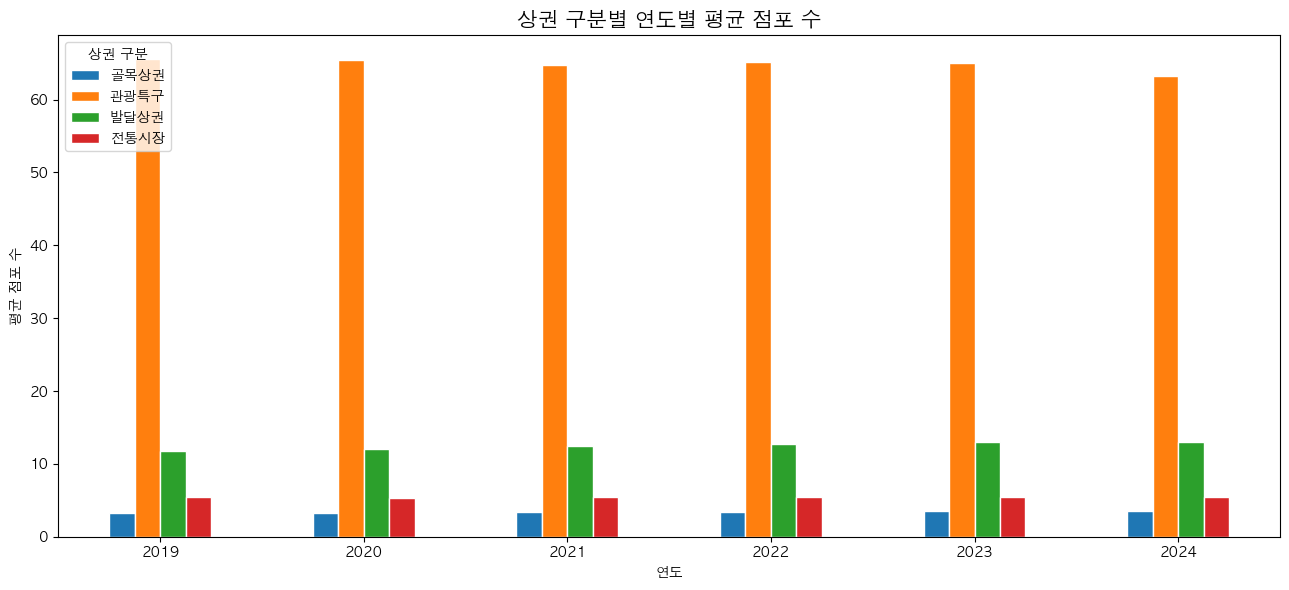

In [10]:
pivot_store.T.plot(kind='bar', figsize=(13, 6), edgecolor='white')

plt.title('상권 구분별 연도별 평균 점포 수', fontsize=15)
plt.xlabel('연도')
plt.ylabel('평균 점포 수')
plt.xticks(rotation=0)
plt.legend(title='상권 구분', loc='upper left')
plt.tight_layout()
plt.show()

# 상권별 폐업률 추이

In [11]:

# 연도 컬럼 추가 (앞 4자리만 추출)
df_전체['연도'] = df_전체['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 연도 + 평균 폐업률
연도별_폐업률= df_전체.groupby(['연도','상권_구분_코드_명'])['폐업_률'].mean().reset_index()

# 피벗
pivot_close = 연도별_폐업률.pivot(index='상권_구분_코드_명', columns='연도', values='폐업_률')
print(pivot_close.round(2))

연도          2019  2020  2021  2022  2023  2024
상권_구분_코드_명                                    
골목상권        2.39  2.18  2.32  2.11  2.52  2.60
관광특구        2.32  2.53  2.55  2.28  2.41  2.29
발달상권        2.56  2.49  2.50  2.22  2.50  2.55
전통시장        2.43  2.22  2.07  2.11  2.38  2.48


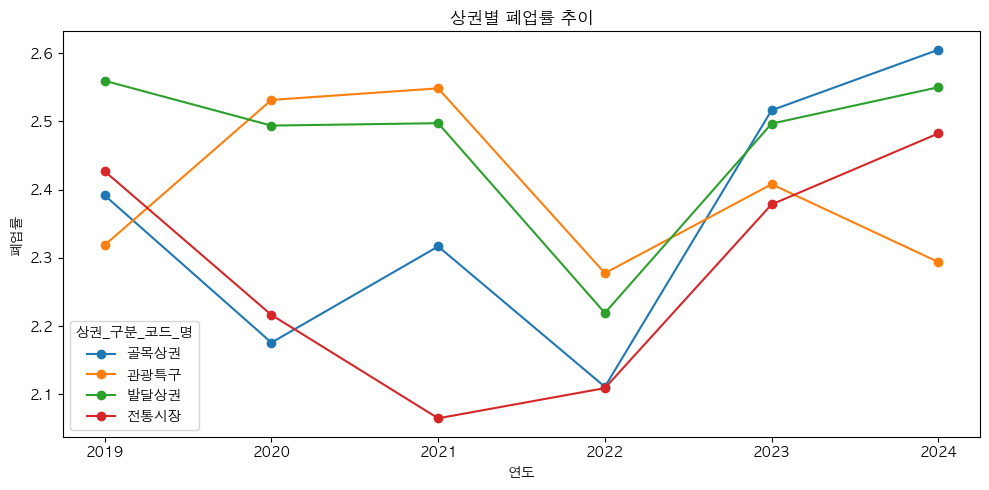

In [12]:
pivot_close.T.plot(kind='line', figsize=(10, 5), marker='o')
plt.title('상권별 폐업률 추이')
plt.ylabel('폐업률')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 상권별 개업률 추이

In [13]:

# 연도 컬럼 추가 (앞 4자리만 추출)
df_전체['연도'] = df_전체['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 연도 + 평균 폐업률
연도별_개업율= df_전체.groupby(['연도','상권_구분_코드_명'])['개업_율'].mean().reset_index()

# 피벗
pivot_open = 연도별_개업율.pivot(index='상권_구분_코드_명', columns='연도', values='개업_율')
print(pivot_open.round(2))

연도          2019  2020  2021  2022  2023  2024
상권_구분_코드_명                                    
골목상권        3.59  3.14  2.90  2.72  3.01  2.17
관광특구        3.78  2.58  2.22  2.46  2.53  1.83
발달상권        3.61  3.06  2.88  2.65  2.85  2.12
전통시장        3.26  2.92  2.59  2.43  2.76  2.20


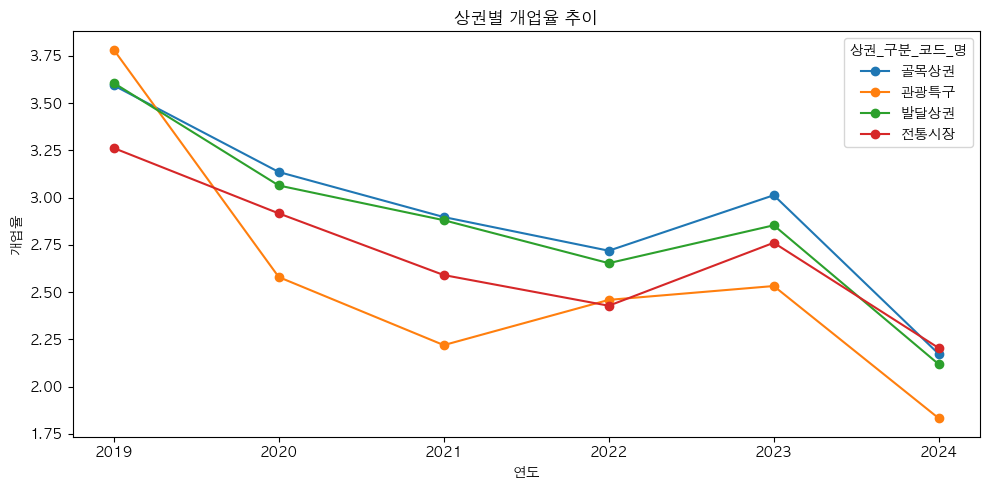

In [14]:
pivot_open.T.plot(kind='line', figsize=(10, 5), marker='o')
plt.title('상권별 개업율 추이')
plt.ylabel('개업율')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 상권별 순성장률

* 상권유형별 순성장률

In [15]:
#19~24년 순성장률
상권_구분_순성장률 = df_전체.groupby('상권_구분_코드_명').agg(
    평균개업률 = ('개업_율', 'mean'),
    평균폐업률 = ('폐업_률', 'mean')
).reset_index()

상권_구분_순성장률['순성장률'] = 상권_구분_순성장률['평균개업률'] - 상권_구분_순성장률['평균폐업률']
상권_구분_순성장률

,상권_구분_코드_명,평균개업률,평균폐업률,순성장률
0,골목상권,2.917878,2.352612,0.565266
1,관광특구,2.562838,2.396561,0.166277
2,발달상권,2.860591,2.469394,0.391198
3,전통시장,2.692410,2.279189,0.413221


In [16]:
#연도별로 순성장률
상권_구분_순성장률 = df_전체.groupby(['연도','상권_구분_코드_명']).agg(
    평균개업률 = ('개업_율', 'mean'),
    평균폐업률 = ('폐업_률', 'mean')
).reset_index()

상권_구분_순성장률['순성장률'] = 상권_구분_순성장률['평균개업률'] - 상권_구분_순성장률['평균폐업률']


pivot = 상권_구분_순성장률.pivot(index='상권_구분_코드_명', columns='연도', values='순성장률')
print(pivot)

연도              2019      2020      2021      2022      2023      2024
상권_구분_코드_명                                                            
골목상권        1.201721  0.959365  0.580136  0.607481  0.496121 -0.432523
관광특구        1.463282  0.047872 -0.329138  0.180939  0.123979 -0.461983
발달상권        1.046707  0.570045  0.382917  0.433504  0.356628 -0.432106
전통시장        0.835089  0.699705  0.524887  0.318343  0.382510 -0.278588


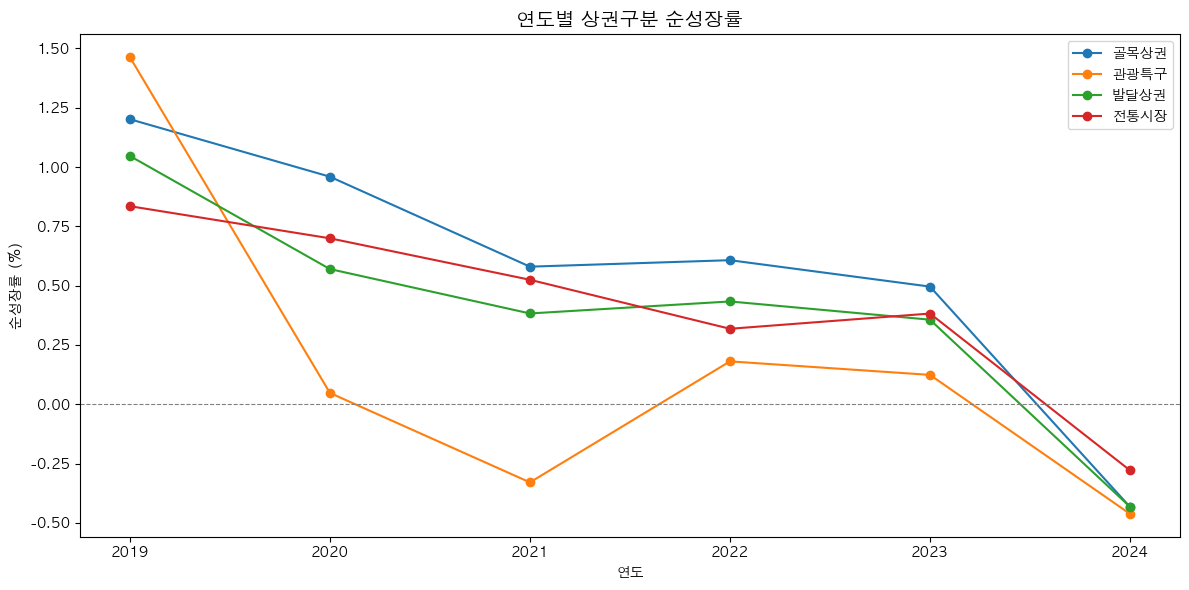

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

for 상권 in pivot.index:
    ax.plot(pivot.columns, pivot.loc[상권], marker='o', label=상권)

ax.set_title('연도별 상권구분 순성장률', fontsize=14)
ax.set_xlabel('연도')
ax.set_ylabel('순성장률 (%)')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)  # 0 기준선
ax.legend(loc='best')
plt.tight_layout()
plt.show()

* 상권명별 순성장률

In [18]:
상권_순성장률 = df_전체.groupby('상권_코드_명').agg(
    평균개업률 = ('개업_율', 'mean'),
    평균폐업률 = ('폐업_률', 'mean')
).reset_index()

상권_순성장률['순성장률'] = 상권_순성장률['평균개업률'] - 상권_순성장률['평균폐업률']
print(상권_순성장률)

            상권_코드_명     평균개업률     평균폐업률      순성장률
0      4.19민주묘지역 2번  2.598808  2.295929  0.302880
1              63빌딩  2.220557  1.625981  0.594575
2     DMC(디지털미디어시티)  3.088218  2.235055  0.853163
3         GS강동자이아파트  2.551364  1.909310  0.642055
4               G타워  4.445153  1.845663  2.599490
...             ...       ...       ...       ...
1645           후암시장  2.425267  1.748221  0.677046
1646        휘문고교사거리  2.084137  1.401402  0.682734
1647           흑리단길  2.310696  2.332767 -0.022071
1648        흑석2치안센터  1.449749  2.248744 -0.798995
1649           흑석시장  3.327160  1.209877  2.117284

[1650 rows x 4 columns]


In [19]:
top_growth    = 상권_순성장률.nlargest(15, '순성장률').reset_index(drop=True)
bottom_growth = 상권_순성장률.nsmallest(15, '순성장률').reset_index(drop=True)

display(top_growth)
display(bottom_growth)

,상권_코드_명,평균개업률,평균폐업률,순성장률
0,상계역전종합상가,15.743119,3.816514,11.926606
1,마곡역(마곡),7.001974,2.227048,4.774926
2,문이교,5.700997,0.996678,4.704319
3,하나고등학교,5.657702,1.048900,4.608802
4,푸른터시장(기능상실),7.236842,2.631579,4.605263
5,서울숲카페거리,6.435125,1.867628,4.567497
6,회기역 2번,6.082822,1.723926,4.358896
7,번동시장,5.172414,1.149425,4.022989
8,영진시장,5.070652,1.358696,3.711957
9,명지전문대,4.070423,0.704225,3.366197


,상권_코드_명,평균개업률,평균폐업률,순성장률
0,NH농협은행 보광동지점,1.509077,3.621152,-2.112076
1,보광시장,1.203216,3.128655,-1.925439
2,역촌중앙시장,1.477273,3.331818,-1.854545
3,장위전통시장,2.516129,4.307097,-1.790968
4,증산골목시장,0.620112,2.404097,-1.783985
5,구반포역,0.897030,2.579538,-1.682508
6,중대부중,0.790698,1.953488,-1.162791
7,본동인정시장(기능상실),1.142615,2.290323,-1.147708
8,강남시장(동작구 강남시장),2.495913,3.585831,-1.089918
9,테크노상가(엘리시움),0.844000,1.890000,-1.046000


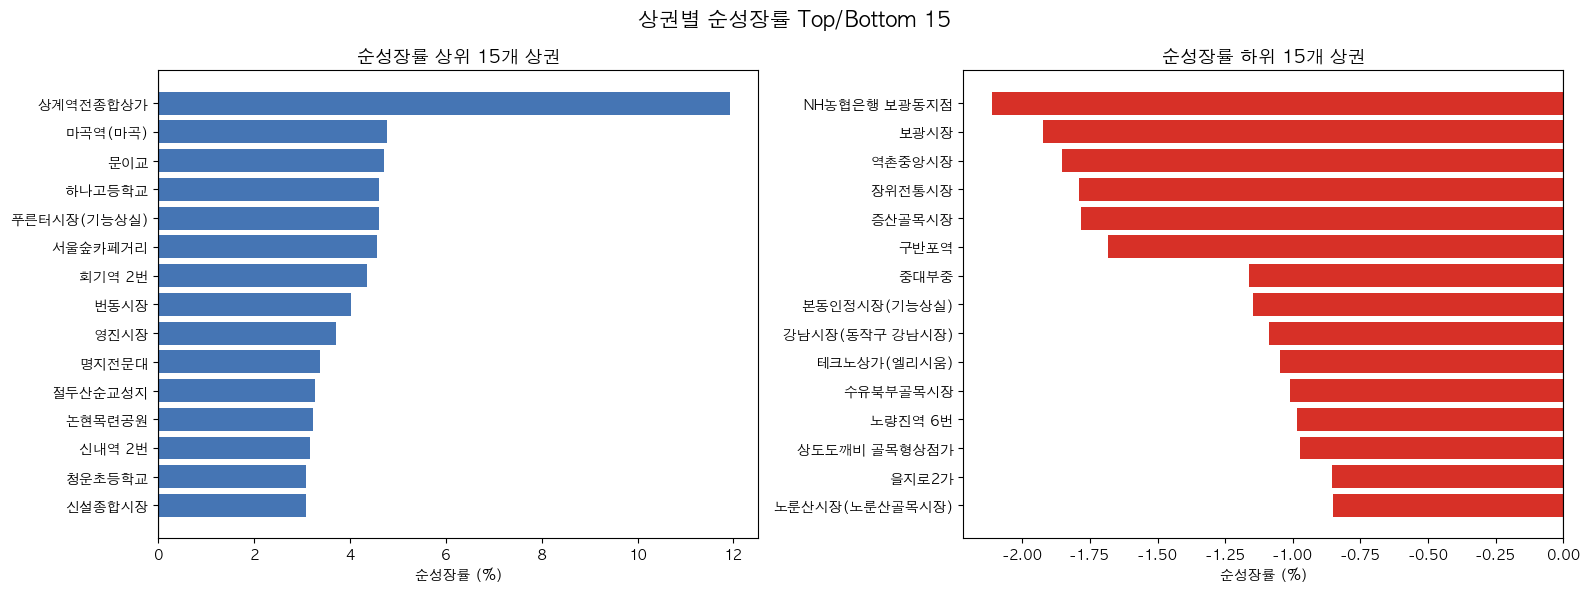

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 성장 상권
top_sorted = top_growth.sort_values('순성장률', ascending=True)
axes[0].barh(top_sorted['상권_코드_명'], top_sorted['순성장률'], color='#4575b4')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('순성장률 상위 15개 상권', fontsize=13)
axes[0].set_xlabel('순성장률 (%)')

# Bottom 15 쇠퇴 상권
bottom_sorted = bottom_growth.sort_values('순성장률', ascending=False)
axes[1].barh(bottom_sorted['상권_코드_명'], bottom_sorted['순성장률'], color='#d73027')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('순성장률 하위 15개 상권', fontsize=13)
axes[1].set_xlabel('순성장률 (%)')

plt.suptitle('상권별 순성장률 Top/Bottom 15', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()